## Data preprocessing


In [1]:
import json
import numpy as np
from gensim.models import KeyedVectors
from gensim.models import Word2Vec
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pandas as pd
import random
import pickle
from utils import load_data, create_embedding_matrix, preprocess_text, to_padding, pad_sequences
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [2]:
class MyTokenizer:
    def __init__(self):
        self.word_index = {"<PAD>": 0, "<UNK>": 1}
        self.idx_to_token = {0: "<PAD>", 1: "<UNK>"}
        
    def fit_on_texts(self, texts):
        for text in texts:
            for word in text.split():
                if word not in self.word_index:
                    self.word_index[word] = len(self.word_index)
                    self.idx_to_token[self.word_index[word]] = word

    def text_to_sequences(self, text):
        return [self.word_index.get(word, self.word_index["<UNK>"]) for word in text.split()]
    
    def texts_to_sequences(self, texts):
        return [[self.word_index.get(word, self.word_index["<UNK>"]) for word in text.split()] for text in texts]


    def encode(self, text, max_length):
        tokens = self.text_to_sequences(text)
        if len(tokens) < max_length:
            tokens += [self.word_index["<PAD>"]] * (max_length - len(tokens))
        else:
            tokens = tokens[:max_length]
        return tokens
    
    def __call__(self, claims, evidences, max_length=512, return_tensors="pt"):
        self.fit_on_texts([claims, evidences])
        encoded_claims = self.encode(claims, max_length)
        encoded_evidences = self.encode(evidences, max_length)
        if return_tensors == "pt":
            return {
                "input_ids": torch.tensor([encoded_claims, encoded_evidences], dtype=torch.long)
            }
        return {"input_ids": [encoded_claims, encoded_evidences]}


In [3]:
# nltk.download('punkt')
stop_words = set(stopwords.words('english'))
stemmer =  SnowballStemmer('english')

train_claims_data = load_data('../data/train-claims.json')
evidence_data = load_data('../data/evidence.json')
dev_claims_data = load_data('../data/dev-claims.json')
# evidence_map = load_data('../data/curated/preprocessed_evidence_map.json')  
evidence_map = load_data('../data/curated/mild_nostopwords_evidence.json')  
filtered_evidence_map = load_data('../data/curated/mild_nostopwords_filtered_evidence.json')

In [4]:
label_mapping = {
    "SUPPORTS": 1,
    "REFUTES": -1,
    # "DISPUTED": 0,
    "NOT_ENOUGH_INFO": 0
}
data_for_dataframe = []
for claim_id, claim_details in train_claims_data.items():
    claim_text = claim_details['claim_text']
    claim_label = claim_details['claim_label']
    eids = claim_details['evidences']
    if claim_label == "DISPUTED":
            continue
    for eid in eids:
        evidence_text = evidence_map[eid]
        
        data_for_dataframe.append({
                'claim_id': claim_id,
                'claim': preprocess_text(claim_text, stemmer=stemmer, stop_words=None),
                'evidence': evidence_text,
                'label': label_mapping[claim_label]
            })

# Create DataFrame
train_claims_df = pd.DataFrame(data_for_dataframe)

# train_claims_df['evidence_texts'] = train_claims_df['evidence'].apply(
#     lambda x: ' '.join([evidence_map[evidence_id] for evidence_id in x])
# )

train_claims_df

,claim_id,claim,evidence,label
0,claim-126,el niño drove record high in global temperatur...,while climat chang can be due to natur forc or...,-1
1,claim-126,el niño drove record high in global temperatur...,this acceler is due most to human caus global ...,-1
2,claim-2510,in 1946 pdo switch to a cool phase,there is evid of revers in the prevail polar m...,1
3,claim-2510,in 1946 pdo switch to a cool phase,the pdo chang to a cool phase the pattern of t...,1
4,claim-2449,januari 2008 cap a 12 month period of global t...,with averag temperatur +8.1 47,0
...,...,...,...,...
3725,claim-502,but abnorm temperatur spike in februari and ea...,the coastlin see signific mild temperatur when...,0
3726,claim-3093,send oscil microwav from an antenna insid a va...,dielectr heat also known as electron heat radi...,1
3727,claim-3093,send oscil microwav from an antenna insid a va...,an exampl is absorpt or emiss of radio wave by...,1
3728,claim-3093,send oscil microwav from an antenna insid a va...,water fat and other substanc in the food absor...,1


In [5]:
label_counts = train_claims_df['label'].value_counts()

label_counts

label
 0    1930
 1    1343
-1     457
Name: count, dtype: int64

In [6]:
# # UnderSample

# # Number of instances in the smallest class
# n_min_samples = train_claims_df['label'].value_counts().min()

# # Perform undersampling
# undersampled_df_list = []

# for label in train_claims_df['label'].unique():
#     # Get a sample of n_min_samples from each label
#     undersampled_df_list.append(train_claims_df[train_claims_df['label'] == label].sample(n=n_min_samples, random_state=42))

# # Concatenate the list into a single DataFrame
# balanced_train_df = pd.concat(undersampled_df_list)

# # Shuffle the dataset
# balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# print("New label counts:\n", balanced_train_df['label'].value_counts())


In [7]:
# X = train_claims_df.drop('label', axis=1) 
# y = train_claims_df['label']

# # It's usually a good idea to scale your data for many ML models
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Split the data into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# # Initialize SMOTE
# smote = SMOTE()

# # Fit SMOTE to the training data
# X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [8]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(train_claims_df, test_size=0.2, random_state=42)
train_df

,claim_id,claim,evidence,label
3326,claim-1558,2nd law of thermodynam contradict greenhous th...,carnot origin argument were made from the view...,0
3552,claim-551,gone are the day when scientist drew a bright ...,these climat are in the polar front region in ...,1
1586,claim-2668,meanwhil it will like to continu to snow in ch...,northeast wind from wintertim cyclon depart so...,0
2791,claim-1121,anoth consequ of the fast melt arctic rais the...,the statement refer the ipcc fourth assess of ...,1
1283,claim-2729,89 percent of the station fail to meet the nat...,this is done use good site and window posit sm...,0
...,...,...,...,...
1130,claim-2871,the un s intergovernment panel on climat chang...,there is widespread support for the ipcc in th...,-1
1294,claim-1963,tallahasse reduc it carbon intens by rough 40 ...,a typic bitumin coal may have an ultim analysi...,0
860,claim-2100,ipcc were wrong about himalayan glacier,the report has also been critic for inclus of ...,1
3507,claim-840,at four degre the dead european heat wave of 2...,the summer 2006 north american heat wave was a...,0


In [9]:
# def text2seq(train_text, test_text, tokenizer):
#     # Fit the tokenizer only on the training data
#     tokenizer.fit_on_texts(train_text)

#     # Tokenize training and testing text
#     train_sequence = tokenizer.texts_to_sequences(train_text)
#     test_sequence = tokenizer.texts_to_sequences(test_text)

#     # Calculate the maximum length of sequences for padding
#     max_length = max(len(seq) for seq in train_sequence + test_sequence)

#     print("Max length:", max_length)

#     with open("tokenizer_train" + ".pickle", "wb") as handle:
#         pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

#     return train_sequence, tokenizer.word_index, test_sequence, max_length


# def to_padding(train_df, test_df, tokenizer):
#     # Tokenize and pad claims
#     x_claims_seq, x_claims_word_index, y_claims_seq, max_claims_length = text2seq(
#         train_df["claim"].tolist(),
#         test_df["claim"].tolist(),
#         tokenizer
#     )

#     # Tokenize and pad evidence texts
#     # Flatten list of evidence texts since they are lists within each row
#     # train_evidences = [text for sublist in train_df["evidence_texts"].tolist() for text in sublist]
#     # test_evidences = [text for sublist in test_df["evidence_texts"].tolist() for text in sublist]

#     x_sents_seq, x_sents_word_index, y_sents_seq, max_sents_length = text2seq(
#         train_df["evidence"].tolist(),
#          test_df["evidence"].tolist(),
#         tokenizer
#     )
def text2seq(train_text, test_text, tokenizer_name, tokenizer):
    # Fit the tokenizer on the entire dataset

    tokenizer.fit_on_texts(train_text + test_text)

    # Calculate the maximum length of sequences for padding
    max_length = max(
        max([len(text.split()) for text in train_text]),
        max([len(text.split()) for text in test_text]),
    )
    print("Max length:", max_length)

    # Tokenize each text individually
    train_sequence = [
        tokenizer.text_to_sequences(text) for text in train_text
    ]  # Process each text separately
    test_sequence = [
        tokenizer.text_to_sequences(text) for text in test_text
    ]  # Process each text separately
    # Dictionary of words to index
    input_text_index = tokenizer.word_index

    # Optionally, save the tokenizer
    with open(tokenizer_name + ".pickle", "wb") as handle:
        pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    return train_sequence, input_text_index, test_sequence, max_length


def to_padding(train_df, test_df, tokenizer):
    # Initialize and fit the tokenizer on claim and evidence separately
    x_claims_seq, x_claims_word_index, y_claims_seq, max_claims_length = text2seq(
        train_df["claim"].tolist(),
        test_df["claim"].tolist(),
        "tokenizer_claims",
        tokenizer,
    )
    x_sents_seq, x_sents_word_index, y_sents_seq, max_sents_length = text2seq(
        train_df["evidence"].tolist(),
        test_df["evidence"].tolist(),
        "tokenizer_evidence",
        tokenizer,
    )

    # Padding sequences
    x_claims_data = pad_sequences(x_claims_seq, maxlen=max_claims_length)
    y_claims_data = pad_sequences(y_claims_seq, maxlen=max_claims_length)
    x_sents_data = pad_sequences(x_sents_seq, maxlen=max_sents_length)
    y_sents_data = pad_sequences(y_sents_seq, maxlen=max_sents_length)

    # x_labels = np.array([label_mapping[label] for label in train_df["label"].tolist()])
    # y_labels = np.array([label_mapping[label] for label in test_df["label"].tolist()])
    x_labels = np.array(train_df["label"].tolist())
    y_labels = np.array(test_df["label"].tolist())

    return (
        x_claims_data, x_sents_data, x_labels, x_claims_word_index,
        x_sents_word_index, y_claims_data, y_sents_data, y_labels
    )

def pad_sequences(sequences, maxlen=None):
    if maxlen is None:
        maxlen = max(len(seq) for seq in sequences)
    padded_sequences = np.zeros(
        (len(sequences), maxlen), dtype=int
    )  # Ensure dtype is int
    for i, sequence in enumerate(sequences):
        end = min(len(sequence), maxlen)
        padded_sequences[i, :end] = sequence[:end]
    return padded_sequences

In [10]:
tokenizer = MyTokenizer()
x_claim, x_sents, x_labels, x_claims_word_index,  x_sents_word_index, y_claims_data, y_sents_data, y_labels = to_padding(train_df, test_df, tokenizer)

print ("x claim word index ", len(x_claims_word_index))
print ("x sent word index ", len(x_sents_word_index))

vocab_size_claims = len(x_claims_word_index) + 2  # +1 for padding, +1 for <UNK>
vocab_size_evidences = len(x_sents_word_index) + 2

Max length: 66
Max length: 262
x claim word index  6508
x sent word index  6508


In [11]:
class EvidenceDataset(Dataset):
    def __init__(self, claims, evidences, labels):
        self.claims = claims
        self.evidences = evidences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        claim = torch.tensor(self.claims[idx], dtype=torch.long)
        evidence = torch.tensor(self.evidences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        return {
            'claims': claim,
            'evidences': evidence,
            'labels': label
        }

# Assuming x_claim, y_claims_data, etc. are numpy arrays or lists of integers
train_dataset = EvidenceDataset(x_claim, x_sents, x_labels)
test_dataset = EvidenceDataset(y_claims_data, y_sents_data, y_labels)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


## Creating the Embedding Matrix

In [12]:
word_vectors = KeyedVectors.load('../data/curated/word2vec.wordvectors', mmap='r')

embedding_dim = 300  # dimension of word2vec vectors
(embed_matrix_claim, embed_dim_claim) = create_embedding_matrix(vocab_size_claims, word_vectors, x_claims_word_index, embedding_dim)
(embed_matrix_evidence, embed_dim_evidence) = create_embedding_matrix(vocab_size_evidences, word_vectors, x_sents_word_index, embedding_dim)

print ("embed_matrix_claim shape ", embed_matrix_claim.shape)
print ("embed_matrix_evidence shape ", embed_matrix_evidence.shape)

embed_matrix_claim shape  (6510, 300)
embed_matrix_evidence shape  (6510, 300)


In [13]:
# from joblib import load

# # Load the TF-IDF vectorizer
# tfidf_vectorizer = load('../tokenizer/tfidf_vectorizer.joblib')

# # Assuming you have lists of claims and evidence texts
# claims_tfidf = tfidf_vectorizer.transform(train_df['claim'])
# evidence_tfidf = tfidf_vectorizer.transform(train_df['evidence'])

# # Convert sparse matrices to dense format for embedding layers if necessary
# embed_matrix_claim = claims_tfidf.toarray()
# embed_matrix_evidence = evidence_tfidf.toarray()

# # Printing shapes to confirm dimensions
# print("Embedding matrix shape for claims: ", embed_matrix_claim.shape)
# print("Embedding matrix shape for evidence: ", embed_matrix_evidence.shape)


In [14]:
# from torch.utils.data import DataLoader, TensorDataset

# # Convert arrays to torch tensors
# claims_tfidf_tensor = torch.FloatTensor(embed_matrix_claim)
# evidence_tfidf_tensor = torch.FloatTensor(embed_matrix_evidence)
# labels_tensor = torch.LongTensor(train_df['label'].values)

# # Combine the tensors into a single dataset
# dataset = TensorDataset(claims_tfidf_tensor, evidence_tfidf_tensor, labels_tensor)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

## Building the LSTM Model

We will build a simple unidirectional LSTM model to compare claim and evidence embeddings.

In [289]:
# class BahdanauAttention(nn.Module):
#     def __init__(self, feature_dim):
#         super(BahdanauAttention, self).__init__()
#         self.feature_dim = feature_dim
#         self.key_layer = nn.Linear(feature_dim, feature_dim, bias=False)
#         self.query_layer = nn.Linear(feature_dim, feature_dim, bias=False)
#         self.energy_layer = nn.Linear(feature_dim, 1, bias=False)
#         self._init_weights()

#     def _init_weights(self):
#         # Initialize weights using Xavier uniform distribution
#         nn.init.xavier_uniform_(self.key_layer.weight)
#         nn.init.xavier_uniform_(self.query_layer.weight)
#         nn.init.xavier_uniform_(self.energy_layer.weight)

#     def forward(self, values):
#         query = self.query_layer(values)
#         keys = self.key_layer(values)
#         energy = torch.tanh(query + keys)
#         energy = self.energy_layer(energy).squeeze(-1)
#         attention_weights = F.softmax(energy, dim=1).unsqueeze(1)
#         context = torch.bmm(attention_weights, values).squeeze(1)
#         return context, attention_weights

class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttentionWrapper, self).__init__()
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads)

    def forward(self, x):
        # Transpose batch and sequence dimensions:
        # nn.MultiheadAttention expects input as (seq_length, batch_size, embedding_dim)
        x = x.transpose(0, 1)
        attn_output, attn_output_weights = self.multihead_attn(x, x, x)
        # Transpose back to (batch_size, seq_length, embedding_dim)
        return attn_output.transpose(0, 1), attn_output_weights

class EvidenceModel(nn.Module):
    def __init__(self, vocab_size_claims, vocab_size_evidences, embed_dim_claim, embed_dim_evidence, num_classes):
        super(EvidenceModel, self).__init__()
        self.embedding_claims = nn.Embedding(vocab_size_claims, embed_dim_claim)
        self.lstm_claims_1 = nn.LSTM(embed_dim_claim, 64, batch_first=True, bidirectional=True)
        self.lstm_claims_2 = nn.LSTM(64*2, 32, batch_first=True)  # unified output size
        self.attention_claims = MultiHeadAttentionWrapper(32, 2) 
        
        self.embedding_evidences = nn.Embedding(vocab_size_evidences, embed_dim_evidence)
        self.lstm_evidences_1 = nn.LSTM(embed_dim_evidence, 64, batch_first=True, bidirectional=True)
        self.lstm_evidences_2 = nn.LSTM(64*2, 32, batch_first=True)  # unified output size
        self.attention_evidences = MultiHeadAttentionWrapper(32, 2)
        
        self.pool = nn.AdaptiveAvgPool1d(1)  # pooling across sequence length
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(32+32, 16)  
        # self.fc1 = nn.Linear(32*2, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, claims_input, evidences_input):
        embedded_claims = self.embedding_claims(claims_input)
        lstm_out_claims, _ = self.lstm_claims_1(embedded_claims)
        lstm_out_claims, _ = self.lstm_claims_2(lstm_out_claims)
        attentive_claims, _ = self.attention_claims(lstm_out_claims)

        embedded_evidences = self.embedding_evidences(evidences_input)
        lstm_out_evidences, _ = self.lstm_evidences_1(embedded_evidences)
        lstm_out_evidences, _ = self.lstm_evidences_2(lstm_out_evidences)
        attentive_evidences, _ = self.attention_evidences(lstm_out_evidences)

        # Pooling each output to reduce dimension to 1
        attentive_claims = self.pool(attentive_claims.transpose(1,2)).squeeze(-1)
        attentive_evidences = self.pool(attentive_evidences.transpose(1,2)).squeeze(-1)

        concatenated = torch.cat((attentive_claims, attentive_evidences), dim=1)
        # concatenated = attentive_claims
        concatenated = self.dropout(concatenated)
        concatenated = self.fc1(concatenated)
        output = self.fc2(concatenated)
        # output = self.fc1(concatenated)
        return torch.tanh(output)

# class TransformerEncoderWrapper(nn.Module):
#     def __init__(self, embed_dim, num_heads, num_layers, dim_feedforward=2048, dropout=0.1):
#         super(TransformerEncoderWrapper, self).__init__()
#         encoder_layers = nn.TransformerEncoderLayer(embed_dim, num_heads, dim_feedforward, dropout)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)

#     def forward(self, x):
#         # Transpose batch and sequence dimensions:
#         # nn.TransformerEncoder expects input as (seq_length, batch_size, embedding_dim)
#         x = x.transpose(0, 1)
#         output = self.transformer_encoder(x)
#         # Transpose back to (batch_size, seq_length, embedding_dim)
#         return output.transpose(0, 1)

# class EvidenceModel(nn.Module):
#     def __init__(self, vocab_size_claims, vocab_size_evidences, embed_dim_claim, embed_dim_evidence, num_classes):
#         super(EvidenceModel, self).__init__()
#         self.embedding_claims = nn.Embedding(vocab_size_claims, embed_dim_claim)
#         self.transformer_claims = TransformerEncoderWrapper(embed_dim_claim, num_heads=2, num_layers=2)
#         self.attention_claims = MultiHeadAttentionWrapper(embed_dim_claim, 2)
         
#         self.embedding_evidences = nn.Embedding(vocab_size_evidences, embed_dim_evidence)
#         self.transformer_evidences = TransformerEncoderWrapper(embed_dim_evidence, num_heads=2, num_layers=2)
#         self.attention_evidences = MultiHeadAttentionWrapper(embed_dim_evidence, 2)
        
#         self.pool = nn.AdaptiveAvgPool1d(1)  # pooling across sequence length
#         self.dropout = nn.Dropout(0.5)
#         self.fc1 = nn.Linear(embed_dim_claim + embed_dim_evidence, 16)  
#         self.fc2 = nn.Linear(16, 1)

#     def forward(self, claims_input, evidences_input):
#         embedded_claims = self.embedding_claims(claims_input)
#         transformer_out_claims = self.transformer_claims(embedded_claims)
#         attentive_claims, _ = self.attention_claims(transformer_out_claims)

#         embedded_evidences = self.embedding_evidences(evidences_input)
#         transformer_out_evidences = self.transformer_evidences(embedded_evidences)
#         attentive_evidences, _ = self.attention_evidences(transformer_out_evidences)

#         # Pooling each output to reduce dimension to 1
#         attentive_claims = self.pool(attentive_claims.transpose(1, 2)).squeeze(-1)
#         attentive_evidences = self.pool(attentive_evidences.transpose(1, 2)).squeeze(-1)

#         concatenated = torch.cat((attentive_claims, attentive_evidences), dim=1)
#         concatenated = self.dropout(concatenated)
#         concatenated = self.fc1(concatenated)
#         output = self.fc2(concatenated)
#         return torch.tanh(output)

# class EvidenceModel(nn.Module):
#     def __init__(self, vocab_size_claims, vocab_size_evidences, embed_dim_claim, embed_dim_evidence, num_classes):
#         super(EvidenceModel, self).__init__()
#         self.embedding_claims = nn.Embedding(vocab_size_claims, embed_dim_claim)
#         self.lstm_claims_1 = nn.LSTM(embed_dim_claim, 256, batch_first=True, bidirectional=True)
#         self.lstm_claims_2 = nn.LSTM(256*2, 64, batch_first=True, bidirectional=True)
#         # self.attention_claims = BahdanauAttention(64*2) 
#         self.attention_claims = MultiHeadAttentionWrapper(64*2, 8)
        
#         self.embedding_evidences = nn.Embedding(vocab_size_evidences, embed_dim_evidence)
#         self.lstm_evidences_1 = nn.LSTM(embed_dim_evidence, 256, batch_first=True, bidirectional=True)
#         self.lstm_evidences_2 = nn.LSTM(256*2, 16, batch_first=True, bidirectional=True)
#         # self.attention_evidences = BahdanauAttention(16*2)
#         self.attention_evidences = MultiHeadAttentionWrapper(16*2, 8)
        
#         self.dropout = nn.Dropout(0.5)
#         self.fc1 = nn.Linear(80*2, 64)  # Adjust according to your concatenated feature size
#         self.fc2 = nn.Linear(64, 1)  # Number of classes

#         # Optionally freeze the embeddings
#         self.embedding_claims.weight.requires_grad = False
#         self.embedding_evidences.weight.requires_grad = False
    
#     def forward(self, claims_input, evidences_input):
#         embedded_claims = self.embedding_claims(claims_input)
#         lstm_out_claims, _ = self.lstm_claims_1(embedded_claims)
#         lstm_out_claims, _ = self.lstm_claims_2(lstm_out_claims)
#         attentive_claims, _ = self.attention_claims(lstm_out_claims)

#         embedded_evidences = self.embedding_evidences(evidences_input)
#         lstm_out_evidences, _ = self.lstm_evidences_1(embedded_evidences)
#         lstm_out_evidences, _ = self.lstm_evidences_2(lstm_out_evidences)
#         attentive_evidences, _ = self.attention_evidences(lstm_out_evidences)

#         concatenated = torch.cat((attentive_claims, attentive_evidences), dim=1)
#         concatenated = self.dropout(concatenated)
#         concatenated = self.fc1(concatenated)
#         output = self.fc2(concatenated)
#         return torch.tanh(output)

# class EvidenceModel(nn.Module):
    # def __init__(self, vocab_size_claims, vocab_size_evidences, embed_dim_claim, embed_dim_evidence, num_classes):
    #     super(EvidenceModel, self).__init__()
    #     self.embedding_claims = nn.Embedding(vocab_size_claims, embed_dim_claim)
    #     self.gru_claims = nn.GRU(embed_dim_claim, 256, batch_first=True, bidirectional=True, num_layers=2)
    #     self.attention_claims = BahdanauAttention(256*2) 
        
    #     self.embedding_evidences = nn.Embedding(vocab_size_evidences, embed_dim_evidence)
    #     self.gru_evidences = nn.GRU(embed_dim_evidence, 256, batch_first=True, bidirectional=True, num_layers=2)
    #     self.attention_evidences = BahdanauAttention(256*2)
        
    #     self.dropout = nn.Dropout(0.5)
    #     self.fc1 = nn.Linear(512*2, 64)  
    #     self.fc2 = nn.Linear(64, 1)  # Number of classes

    #     # Optionally freeze the embeddings
    #     self.embedding_claims.weight.requires_grad = False
    #     self.embedding_evidences.weight.requires_grad = False
    
    # def forward(self, claims_input, evidences_input):
    #     embedded_claims = self.embedding_claims(claims_input)
    #     gru_out_claims, _ = self.gru_claims(embedded_claims)
    #     attentive_claims, _ = self.attention_claims(gru_out_claims)

    #     embedded_evidences = self.embedding_evidences(evidences_input)
    #     gru_out_evidences, _ = self.gru_evidences(embedded_evidences)
    #     attentive_evidences, _ = self.attention_evidences(gru_out_evidences)

    #     concatenated = torch.cat((attentive_claims, attentive_evidences), dim=1)
    #     concatenated = self.dropout(concatenated)
    #     concatenated = self.fc1(concatenated)
    #     output = self.fc2(concatenated)
    #     return torch.tanh(output)


def train_model(model, train_loader, val_loader, epochs, device):
    model_path = '../checkpoints/M2HAttn_blstm_claimonly_nodis_combinedloss.pth'
    best_val_loss = float('inf')
    patience = 2
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            claims = batch['claims'].to(device)
            evidences = batch['evidences'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(claims, evidences).squeeze(1)
            # print(outputs.shape)
            # print(labels.shape)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        val_loss = evaluate(model, val_loader, device)
        print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_path)
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            claims = batch['claims'].to(device)
            evidences = batch['evidences'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(claims, evidences).squeeze(1)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

def predict(model, data_loader, device):
    model.eval() 
    predictions = []
    with torch.no_grad():  
        for batch in data_loader:
            claims = batch['claims'].to(device)
            evidences = batch['evidences'].to(device)
            outputs = model(claims, evidences)
            predictions.append(outputs.cpu())  # Move predictions to CPU
            
    # Concatenate the list of tensors into a single tensor
    predictions = torch.cat(predictions, dim=0)
    return predictions


In [349]:
import torch.nn.functional as F

class CustomCrossEntropyLoss(nn.Module):
    def __init__(self):
        super(CustomCrossEntropyLoss, self).__init__()

    def forward(self, y_true, y_pred):
        # Assuming y_true contains values in {-1, 0, 1}
        # Map y_true to {0, 1, 2} for one-hot encoding
        y_true_mapped = (y_true + 1).long()
        y_true_one_hot = F.one_hot(y_true_mapped, num_classes=3).float()
        
        # Ensure y_pred is in [-1, 1]
        y_pred_clamped = torch.clamp(y_pred, -1, 1)
        
        # Create logits for the three classes
        logits = torch.stack([1 - y_pred_clamped, y_pred_clamped, y_pred_clamped + 1], dim=1)
        
        # Apply log-softmax to the logits
        log_probs = F.log_softmax(logits, dim=1)
        
        # Compute the loss
        loss = -torch.sum(y_true_one_hot * log_probs, dim=1).mean()
        
        return loss

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.mse_loss = nn.MSELoss()
        self.cross_entropy_loss = CustomCrossEntropyLoss()

    def forward(self, y_true, y_pred):
        mse = self.mse_loss(y_true.float(), y_pred)
        cross_entropy = self.cross_entropy_loss(y_true, y_pred)
        return self.alpha * mse + (1 - self.alpha) * cross_entropy
    
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super(CombinedLoss, self).__init__()
        self.smooth_l1_loss = nn.SmoothL1Loss()
        self.alpha = alpha
        self.mse_loss = nn.MSELoss()

    def forward(self, y_true, y_pred):
        # Ensure y_pred is in [-1, 1]
        y_pred = torch.clamp(y_pred, -1, 1)
        
        # Regression part: Smooth L1 Loss between predicted and true values
        regression_loss = self.smooth_l1_loss(y_pred, y_true.float())

        # Classification-like part: Cross-entropy for discrete labels
        # Map y_true to {0, 1, 2} for one-hot encoding
        y_true_mapped = (y_true + 1).long()
        y_true_one_hot = F.one_hot(y_true_mapped, num_classes=3).float()

        # Create logits for the three classes
        logits = torch.stack([1 - y_pred, y_pred, y_pred + 1], dim=1)
        
        # Apply log-softmax to the logits
        log_probs = F.log_softmax(logits, dim=1)
        
        # Compute the cross-entropy loss
        classification_loss = -torch.sum(y_true_one_hot * log_probs, dim=1).mean()
        mse = self.mse_loss(y_true.float(), y_pred)

        # Combine the two losses
        combined_loss = self.alpha * regression_loss + (1 - self.alpha) * mse
        
        return combined_loss

# # Example usage
# # x0: tensor of true values, x: tensor of predicted values
# x0 = torch.tensor([1.0, -1.0, 0.0])
# x = torch.tensor([0.8, -0.9, 0.1])

# loss_function = CustomLoss()
# loss = loss_function(x0, x)
# print(loss)


In [370]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EvidenceModel(vocab_size_claims, vocab_size_evidences, embed_dim_claim, embed_dim_evidence, 3).to(device)
# model = model = ClaimEvidenceModel(vocab_size_claims+vocab_size_evidences, embedding_dim, lstm_dim=128)
# criterion = nn.NLLLoss()  # Use Negative Log-Likelihood Loss with log_softmax
# optimizer = optim.Adam(model.parameters(), lr=0.0001)
# criterion = nn.CrossEntropyLoss()
# criterion = nn.MSELoss()
# criterion = nn.BCELoss()
# criterion = nn.L1Loss()
criterion = CombinedLoss(alpha=0.5)
# criterion = nn.SmoothL1Loss()
# criterion = CustomLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Adding weight decay for L2 regularization


In [371]:

# Train the model
epochs = 60
train_model(model, train_loader, test_loader, epochs, device)

Epoch 1, Train Loss: 0.3247, Val Loss: 0.3103
Epoch 2, Train Loss: 0.3246, Val Loss: 0.3072
Epoch 3, Train Loss: 0.3117, Val Loss: 0.2760
Epoch 4, Train Loss: 0.2223, Val Loss: 0.1694
Epoch 5, Train Loss: 0.1171, Val Loss: 0.1248
Epoch 6, Train Loss: 0.0671, Val Loss: 0.1019
Epoch 7, Train Loss: 0.0401, Val Loss: 0.0842
Epoch 8, Train Loss: 0.0281, Val Loss: 0.0827
Epoch 9, Train Loss: 0.0191, Val Loss: 0.0717
Epoch 10, Train Loss: 0.0144, Val Loss: 0.0647
Epoch 11, Train Loss: 0.0122, Val Loss: 0.0648
Epoch 12, Train Loss: 0.0098, Val Loss: 0.0683
Early stopping at epoch 12


In [360]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

# Load the best model
# model.load_state_dict(torch.load('lstm_evidence_retrieval.pth'))
# model.load_state_dict(torch.load('model/BAttn_lstm2_evidence_retrieval_1-10.pth'))

def tag_label(output_value, threshold):
    if output_value > threshold:
        return 1
    if output_value < -threshold:
        return -1
    return 0
# Test loader setup like train_loader and val_loader
test_loss = evaluate(model, test_loader, device)
print("Test loss", test_loss)
threshold = 0.2
# Prediction and performance metrics
y_pred = []
y_true = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        claims = batch['claims'].to(device)
        evidences = batch['evidences'].to(device)
        labels = batch['labels'].cpu().numpy()
        outputs = model(claims, evidences).cpu().numpy()[:, 0]  # Adjust shape handling as necessary
        predicted_labels = [tag_label(output, threshold) for output in outputs]
        y_pred.extend(predicted_labels)
        y_true.extend(labels)

# Calculate precision, recall, and F-score
# precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
# print("Score of LSTM", {'precision': precision, 'recall': recall, 'fscore': fscore})
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F-score:", fscore)

Test loss 0.053244963909188904
Mean Squared Error: 0.13002680965147453
Mean Absolute Error: 0.08176943699731903
R-squared: 0.6846806986711472
Accuracy: 0.9423592493297587
Precision: 0.9093372240315665
Recall: 0.9300390526581003
F-score: 0.9186969110224013


## Predict

In [361]:
# dev_predicted = load_data("../data/output/dev_predict.json")
dev_predicted = load_data("../data/dev-claims.json")
test_data = load_data("../data/output/test-claim-output.json")

# model.load_state_dict(torch.load('../checkpoints/BAttn_blstm_classify_nodis.pth'))

In [362]:
data_for_dataframe = []
label_only = []
for claim_id, claim_details in dev_predicted.items():
    claim_text = preprocess_text(claim_details['claim_text'], stemmer, stop_words=None)
    eids = claim_details['evidences']
    label_only.append({
        'claim_id': claim_id,
        'claim_label': claim_details['claim_label']
    })
    data_for_dataframe.append({
			'claim_id': claim_id,
            'claim': claim_text,
            'original_claim': claim_details['claim_text'],
            'evidence': eids
        })
    
# Create DataFrame
output_df = pd.DataFrame(data_for_dataframe)
label_df = pd.DataFrame(label_only)
output_df

,claim_id,claim,original_claim,evidence
0,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]"
1,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2..."
2,claim-1266,this mean that the world is now 1c warmer than...,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]"
3,claim-871,as it happen zika may also be a good model of ...,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28..."
4,claim-2164,greenland has onli lost a tini fraction of it ...,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947..."
...,...,...,...,...
149,claim-2400,to sudden label co2 as a pollut is a disservic...,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85..."
150,claim-204,after a natur orbit driven warm atmospher carb...,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20..."
151,claim-1426,mani of the world s coral reef are alreadi bar...,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1..."
152,claim-698,a recent studi led by lawrenc livermor nation ...,A recent study led by Lawrence Livermore Natio...,[evidence-660755]


In [363]:
data_for_dataframe = []
for claim_id, claim_details in dev_predicted.items():
    claim_text = preprocess_text(claim_details['claim_text'], stemmer, stop_words=None)
    eids = claim_details['evidences']
    for eid in eids:
        evidence_text = evidence_map[eid]
        data_for_dataframe.append({
                'claim_id': claim_id,
                'claim': claim_text,
                'original_claim': claim_details['claim_text'],
                'evidence_id': eid,
                'evidence_text': evidence_text
            })
    
# Create DataFrame
dev_claims_df = pd.DataFrame(data_for_dataframe)
dev_claims_df 

,claim_id,claim,original_claim,evidence_id,evidence_text
0,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,evidence-67732,citat need south australia has the highest ret...
1,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,evidence-572512,south australia has the highest power price in...
2,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,evidence-996421,the 2011 unep green economi report state that ...
3,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,evidence-1080858,with a market share of 30 and potenti clean el...
4,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,evidence-208053,in the modern era emiss to the atmospher from ...
...,...,...,...,...,...
486,claim-1426,mani of the world s coral reef are alreadi bar...,Many of the world’s coral reefs are already ba...,evidence-288294,aquacultur is show promis as a potenti effect ...
487,claim-1426,mani of the world s coral reef are alreadi bar...,Many of the world’s coral reefs are already ba...,evidence-946262,this can rapid result in transit to barren lan...
488,claim-698,a recent studi led by lawrenc livermor nation ...,A recent study led by Lawrence Livermore Natio...,evidence-660755,a 2007 studi by david douglass and cowork conc...
489,claim-1021,the coral may save themselv as mani other crea...,"The corals may save themselves, as many other ...",evidence-242575,the poleward migrat of coral speci refer to th...


In [364]:
with open('tokenizer_claims.pickle', 'rb') as handle:
	claims_tokenizer = pickle.load(handle)
	
with open('tokenizer_evidence.pickle', 'rb') as handle:
	evidence_tokenizer = pickle.load(handle)

max_claims_length = 68
max_sents_length = 264

dev_sents_text = filtered_evidence_map.values()

# Tokenize the preprocessed text
dev_claims = claims_tokenizer.texts_to_sequences(dev_claims_df["claim"].tolist())
dev_sents = evidence_tokenizer.texts_to_sequences(dev_claims_df['evidence_text'].tolist())

# Padding sequences to ensure uniform input size
dev_claims = pad_sequences(dev_claims, maxlen=max_claims_length)
dev_sents = pad_sequences(dev_sents, maxlen=max_sents_length)

# Print shapes
print("dev claims shape:", dev_claims.shape)
print("dev sents shape:", dev_sents.shape)

dev claims shape: (491, 68)
dev sents shape: (491, 264)


In [365]:
# model.load_state_dict(torch.load('../checkpoints/BAttn_lstm2_evidence_retrieval_1-10.pth'))
model = model.to(device)  
model.eval()  

dev_claims = torch.tensor(dev_claims).to(device)  
dev_sents = torch.tensor(dev_sents).to(device)
claim_ids = dev_claims_df["claim_id"].tolist()

batch_size = 128  
all_predictions = []

# Ensure batching through the whole dataset
for i in range(0, dev_claims.shape[0], batch_size):
    claim_batch = dev_claims[i:i+batch_size]
    sent_batch = dev_sents[i:i+batch_size]

    with torch.no_grad():
        outputs = model(claim_batch, sent_batch).squeeze(1).cpu().numpy()

    # Collect batch predictions with claim_ids
    batch_predictions = list(zip(claim_ids[i:i+batch_size], outputs))
    all_predictions.extend(batch_predictions)

results_df = pd.DataFrame(all_predictions, columns=["claim_id", "prediction"])
results_df
# results_df.to_csv("../data/output/BAttn_blstm_result_t70_10.csv", index=False)


,claim_id,prediction
0,claim-752,-0.920040
1,claim-752,-0.920041
2,claim-375,0.998471
3,claim-375,0.998472
4,claim-375,0.998470
...,...,...
486,claim-1426,0.999488
487,claim-1426,0.999488
488,claim-698,0.980719
489,claim-1021,0.612205


In [366]:
from collections import Counter

def tag_label(prediction, tl=-0.2, th=0.2):
    if prediction > th:
        return 1
    if prediction < tl:
        return -1
    return 0

# Apply predictions to each row in the DataFrame
results_df['prediction'] = results_df.apply(lambda row: tag_label(row['prediction'], tl=-0.2, th=0.20), axis=1)

def determine_final_label(labels):
    label_counts = Counter(labels)
    if len(set(labels)) == 1:
        return labels.iloc[0]
    if (1 in labels) and (-1 in labels):
        return 2
    if set(labels) <= {0, 1}:
        # Return the label which has the majority
        if label_counts[1] > label_counts[0]:
            return 1
        else:
            return 0
    else:
        return 2 # conflicting labels

final_labels = results_df.groupby('claim_id')['prediction'].agg(determine_final_label)

output_df = output_df.join(final_labels, on='claim_id')

output_df

,claim_id,claim,original_claim,evidence,prediction
0,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]",-1
1,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2...",1
2,claim-1266,this mean that the world is now 1c warmer than...,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]",0
3,claim-871,as it happen zika may also be a good model of ...,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28...",1
4,claim-2164,greenland has onli lost a tini fraction of it ...,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947...",-1
...,...,...,...,...,...
149,claim-2400,to sudden label co2 as a pollut is a disservic...,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85...",0
150,claim-204,after a natur orbit driven warm atmospher carb...,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20...",0
151,claim-1426,mani of the world s coral reef are alreadi bar...,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1...",1
152,claim-698,a recent studi led by lawrenc livermor nation ...,A recent study led by Lawrence Livermore Natio...,[evidence-660755],1


In [66]:
label_mapping

{'SUPPORTS': 1, 'REFUTES': -1, 'NOT_ENOUGH_INFO': 0}

In [367]:
def map_to_label(prediction):
    if prediction == 0:
        return "NOT_ENOUGH_INFO"
    if prediction == -1:
        return "REFUTES"
    if prediction == 1:
        return "SUPPORTS"
    return "DISPUTED"

output_df["claim_label"] = output_df["prediction"].apply(lambda x: map_to_label(x))

output_df

,claim_id,claim,original_claim,evidence,prediction,claim_label
0,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]",-1,REFUTES
1,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2...",1,SUPPORTS
2,claim-1266,this mean that the world is now 1c warmer than...,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]",0,NOT_ENOUGH_INFO
3,claim-871,as it happen zika may also be a good model of ...,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28...",1,SUPPORTS
4,claim-2164,greenland has onli lost a tini fraction of it ...,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947...",-1,REFUTES
...,...,...,...,...,...,...
149,claim-2400,to sudden label co2 as a pollut is a disservic...,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85...",0,NOT_ENOUGH_INFO
150,claim-204,after a natur orbit driven warm atmospher carb...,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20...",0,NOT_ENOUGH_INFO
151,claim-1426,mani of the world s coral reef are alreadi bar...,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1...",1,SUPPORTS
152,claim-698,a recent studi led by lawrenc livermor nation ...,A recent study led by Lawrence Livermore Natio...,[evidence-660755],1,SUPPORTS


In [368]:
output_df.drop(columns=["claim", "prediction"], inplace=True)
output_df.rename(columns={"original_claim": "claim_text", "evidence": "evidences"}, inplace=True)
output_df.set_index('claim_id', inplace=True)
output_df

,claim_text,evidences,claim_label
claim_id,,,
claim-752,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]",REFUTES
claim-375,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2...",SUPPORTS
claim-1266,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]",NOT_ENOUGH_INFO
claim-871,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28...",SUPPORTS
claim-2164,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947...",REFUTES
...,...,...,...
claim-2400,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85...",NOT_ENOUGH_INFO
claim-204,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20...",NOT_ENOUGH_INFO
claim-1426,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1...",SUPPORTS


In [369]:
result = output_df.to_json(orient="index")
with open('../data/output/M2HAttn-blstm2-nodis-combineloss2_output.json', 'w') as f:
    f.write(result)

In [348]:
import torch
torch.__version__

'2.3.0+cu118'

In [60]:
import ast
results_df = pd.read_csv("../data/output/BAttn_blstm_result_t70_10.csv")
results_df['evidences_id'] = results_df['evidences_id'].apply(ast.literal_eval)
results_df

,claim_id,evidences_id
0,claim-752,"[evidence-315, evidence-337, evidence-842, evi..."
1,claim-375,"[evidence-315, evidence-337, evidence-842, evi..."
2,claim-1266,"[evidence-315, evidence-337, evidence-842, evi..."
3,claim-871,"[evidence-315, evidence-337, evidence-842, evi..."
4,claim-2164,"[evidence-315, evidence-337, evidence-842, evi..."
...,...,...
149,claim-2400,"[evidence-315, evidence-337, evidence-842, evi..."
150,claim-204,"[evidence-315, evidence-337, evidence-842, evi..."
151,claim-1426,"[evidence-315, evidence-337, evidence-842, evi..."
152,claim-698,"[evidence-315, evidence-337, evidence-842, evi..."


# Test Prediction

In [119]:
test_data = load_data("../data/output/test-claim-output.json")

In [120]:
data_for_dataframe = []
for claim_id, claim_details in test_data.items():
    claim_text = preprocess_text(claim_details['claim_text'], stemmer, stop_words)
    eids = claim_details['evidences']

    data_for_dataframe.append({
			'claim_id': claim_details['claim_id'],
            'claim': claim_text,
            'original_claim': claim_details['claim_text'],
            'evidence': eids
        })
    
# Create DataFrame
output_df = pd.DataFrame(data_for_dataframe)
label_df = pd.DataFrame(label_only)
output_df

,claim_id,claim,original_claim,evidence
0,claim-2967,contribut wast heat global climat 0 028 w m2,The contribution of waste heat to the global c...,"[evidence-163066, evidence-302863, evidence-30..."
1,claim-979,warm weather worsen recent five year drought i...,“Warm weather worsened the most recent five-ye...,"[evidence-434312, evidence-957389, evidence-17..."
2,claim-1609,greenland lost tini fraction ice mass,Greenland has only lost a tiny fraction of its...,"[evidence-776422, evidence-1200633, evidence-9..."
3,claim-1020,global reef crisi necessarili mean extinct cor...,“The global reef crisis does not necessarily m...,"[evidence-670186, evidence-161852, evidence-64..."
4,claim-2599,small amount activ substanc caus larg effect,Small amounts of very active substances can ca...,"[evidence-432221, evidence-253763, evidence-83..."
...,...,...,...,...
148,claim-293,measur equip get old need replac often requir ...,When the measuring equipment gets old and need...,"[evidence-915220, evidence-857605, evidence-11..."
149,claim-910,cement iron steel petroleum refin industri cou...,"The cement, iron and steel, and petroleum refi...","[evidence-309027, evidence-117114, evidence-19..."
150,claim-2815,new peer review studi surfac warm solar cycl f...,A new peer-reviewed study on Surface Warming a...,"[evidence-333931, evidence-700183, evidence-78..."
151,claim-1652,strong co2 effect observ mani differ measur,The strong CO2 effect has been observed by man...,"[evidence-16131, evidence-1652, evidence-132348]"


In [121]:

data_for_dataframe = []
for claim_id, claim_details in test_data.items():
    claim_text = preprocess_text(claim_details['claim_text'], stemmer, stop_words=None)
    eids = claim_details['evidences']
    for eid in eids:
        evidence_text = evidence_map[eid]
        data_for_dataframe.append({
                'claim_id': claim_details['claim_id'],
                'claim': claim_text,
                'original_claim': claim_details['claim_text'],
                'evidence_id': eid,
                'evidence_text': evidence_text
            })
    
# Create DataFrame
test_claims_df = pd.DataFrame(data_for_dataframe)
test_claims_df

,claim_id,claim,original_claim,evidence_id,evidence_text
0,claim-2967,the contribut of wast heat to the global clima...,The contribution of waste heat to the global c...,evidence-163066,his develop and use of global climat model has...
1,claim-2967,the contribut of wast heat to the global clima...,The contribution of waste heat to the global c...,evidence-302863,the result low temperatur wast heat is then us...
2,claim-2967,the contribut of wast heat to the global clima...,The contribution of waste heat to the global c...,evidence-308923,global forc from wast heat was 0.028 in 2005
3,claim-979,warm weather worsen the most recent five year ...,“Warm weather worsened the most recent five-ye...,evidence-434312,the rainiest month is februari with an averag ...
4,claim-979,warm weather worsen the most recent five year ...,“Warm weather worsened the most recent five-ye...,evidence-957389,between 2011 and 2014 california experienc the...
...,...,...,...,...,...
454,claim-1652,the strong co2 effect has been observ by mani ...,The strong CO2 effect has been observed by man...,evidence-1652,it has been observ that
455,claim-1652,the strong co2 effect has been observ by mani ...,The strong CO2 effect has been observed by man...,evidence-132348,her abil to see event befor they happen was ob...
456,claim-1212,in technic lingo the so call social cost of ca...,"(In technical lingo, the so-called social cost...",evidence-78145,a negat extern is ani differ between the priva...
457,claim-1212,in technic lingo the so call social cost of ca...,"(In technical lingo, the so-called social cost...",evidence-594802,cost benefit integr assess model are the main ...


In [122]:
with open('tokenizer_claims.pickle', 'rb') as handle:
	claims_tokenizer = pickle.load(handle)
	
with open('tokenizer_evidence.pickle', 'rb') as handle:
	evidence_tokenizer = pickle.load(handle)

max_claims_length = 68
max_sents_length = 264

test_sents_text = filtered_evidence_map.values()

# Tokenize the preprocessed text
test_claims = claims_tokenizer.texts_to_sequences(test_claims_df["claim"].tolist())
test_sents = evidence_tokenizer.texts_to_sequences(test_claims_df['evidence_text'].tolist())

# Padding sequences to ensure uniform input size
test_claims = pad_sequences(test_claims, maxlen=max_claims_length)
test_sents = pad_sequences(test_sents, maxlen=max_sents_length)

# Print shapes
print("dev claims shape:", test_claims.shape)
print("dev sents shape:", test_sents.shape)

dev claims shape: (459, 68)
dev sents shape: (459, 264)


In [123]:
# model.load_state_dict(torch.load('../checkpoints/BAttn_lstm2_evidence_retrieval_1-10.pth'))
model = model.to(device)  
model.eval()  

test_claims = torch.tensor(test_claims).to(device)  
test_sents = torch.tensor(test_sents).to(device)
claim_ids = test_claims_df["claim_id"].tolist()

batch_size = 128  
all_predictions = []

# Ensure batching through the whole dataset
for i in range(0, test_claims.shape[0], batch_size):
    claim_batch = test_claims[i:i+batch_size]
    sent_batch = test_sents[i:i+batch_size]

    with torch.no_grad():
        outputs = model(claim_batch, sent_batch).squeeze(1).cpu().numpy()

    # Collect batch predictions with claim_ids
    batch_predictions = list(zip(claim_ids[i:i+batch_size], outputs))
    all_predictions.extend(batch_predictions)

results_df = pd.DataFrame(all_predictions, columns=["claim_id", "prediction"])
results_df
# results_df.to_csv("../data/output/BAttn_blstm_result_t70_10.csv", index=False)


,claim_id,prediction
0,claim-2967,-0.281044
1,claim-2967,-0.281277
2,claim-2967,-0.280414
3,claim-979,0.844748
4,claim-979,0.844561
...,...,...
454,claim-1652,0.996333
455,claim-1652,0.996321
456,claim-1212,-0.278977
457,claim-1212,-0.280448


In [124]:
def tag_label(prediction, tl=-0.2, th=0.2):
    if prediction > th:
        return 1
    if prediction < tl:
        return -1
    return 0

# Apply predictions to each row in the DataFrame
results_df['prediction'] = results_df.apply(lambda row: tag_label(row['prediction'], tl=-0.2, th=0.20), axis=1)

def determine_final_label(labels):
    label_counts = Counter(labels)
    if len(set(labels)) == 1:
        return labels.iloc[0]
    if (1 in labels) and (-1 in labels):
        return 2
    if set(labels) <= {0, 1}:
        # Return the label which has the majority
        if label_counts[1] > label_counts[0]:
            return 1
        else:
            return 0
    else:
        return 2 # conflicting labels

final_labels = results_df.groupby('claim_id')['prediction'].agg(determine_final_label)

output_df = output_df.join(final_labels, on='claim_id')

def map_to_label(prediction):
    if prediction == 0:
        return "NOT_ENOUGH_INFO"
    if prediction == -1:
        return "REFUTES"
    if prediction == 1:
        return "SUPPORTS"
    return "DISPUTED"

output_df["claim_label"] = output_df["prediction"].apply(lambda x: map_to_label(x))

output_df

,claim_id,claim,original_claim,evidence,prediction,claim_label
0,claim-2967,contribut wast heat global climat 0 028 w m2,The contribution of waste heat to the global c...,"[evidence-163066, evidence-302863, evidence-30...",-1,REFUTES
1,claim-979,warm weather worsen recent five year drought i...,“Warm weather worsened the most recent five-ye...,"[evidence-434312, evidence-957389, evidence-17...",1,SUPPORTS
2,claim-1609,greenland lost tini fraction ice mass,Greenland has only lost a tiny fraction of its...,"[evidence-776422, evidence-1200633, evidence-9...",-1,REFUTES
3,claim-1020,global reef crisi necessarili mean extinct cor...,“The global reef crisis does not necessarily m...,"[evidence-670186, evidence-161852, evidence-64...",-1,REFUTES
4,claim-2599,small amount activ substanc caus larg effect,Small amounts of very active substances can ca...,"[evidence-432221, evidence-253763, evidence-83...",0,NOT_ENOUGH_INFO
...,...,...,...,...,...,...
148,claim-293,measur equip get old need replac often requir ...,When the measuring equipment gets old and need...,"[evidence-915220, evidence-857605, evidence-11...",0,NOT_ENOUGH_INFO
149,claim-910,cement iron steel petroleum refin industri cou...,"The cement, iron and steel, and petroleum refi...","[evidence-309027, evidence-117114, evidence-19...",-1,REFUTES
150,claim-2815,new peer review studi surfac warm solar cycl f...,A new peer-reviewed study on Surface Warming a...,"[evidence-333931, evidence-700183, evidence-78...",1,SUPPORTS
151,claim-1652,strong co2 effect observ mani differ measur,The strong CO2 effect has been observed by man...,"[evidence-16131, evidence-1652, evidence-132348]",1,SUPPORTS


In [125]:
output_df.drop(columns=["claim", "prediction"], inplace=True)
output_df.rename(columns={"original_claim": "claim_text", "evidence": "evidences"}, inplace=True)
output_df.set_index('claim_id', inplace=True)
output_df

,claim_text,evidences,claim_label
claim_id,,,
claim-2967,The contribution of waste heat to the global c...,"[evidence-163066, evidence-302863, evidence-30...",REFUTES
claim-979,“Warm weather worsened the most recent five-ye...,"[evidence-434312, evidence-957389, evidence-17...",SUPPORTS
claim-1609,Greenland has only lost a tiny fraction of its...,"[evidence-776422, evidence-1200633, evidence-9...",REFUTES
claim-1020,“The global reef crisis does not necessarily m...,"[evidence-670186, evidence-161852, evidence-64...",REFUTES
claim-2599,Small amounts of very active substances can ca...,"[evidence-432221, evidence-253763, evidence-83...",NOT_ENOUGH_INFO
...,...,...,...
claim-293,When the measuring equipment gets old and need...,"[evidence-915220, evidence-857605, evidence-11...",NOT_ENOUGH_INFO
claim-910,"The cement, iron and steel, and petroleum refi...","[evidence-309027, evidence-117114, evidence-19...",REFUTES
claim-2815,A new peer-reviewed study on Surface Warming a...,"[evidence-333931, evidence-700183, evidence-78...",SUPPORTS


In [126]:
result = output_df.to_json(orient="index")
with open('../data/test-claims-output.json', 'w') as f:
    f.write(result)

# Analysis

In [52]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

y_true = label_df["claim_label"].tolist()
y_pred = output_df["claim_label"].tolist()
y_true_processed = ['Unknown' if label is None else label for label in y_true]
y_pred_processed = ['Unknown' if pred is None else pred for pred in y_pred]

# Calculate the confusion matrix
cm = confusion_matrix(y_true_processed, y_pred_processed, labels=np.unique(y_true_processed))


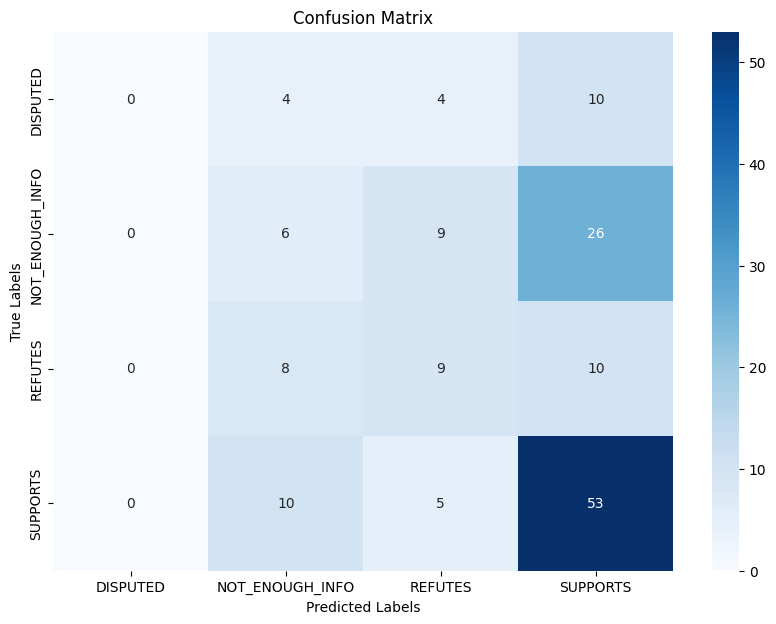

In [53]:
# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

C:\Users\Clare\AppData\Local\Temp\ipykernel_16824\1162323039.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='claim_label', data=output_df, palette='Set2')  # Set2 is a nice color palette


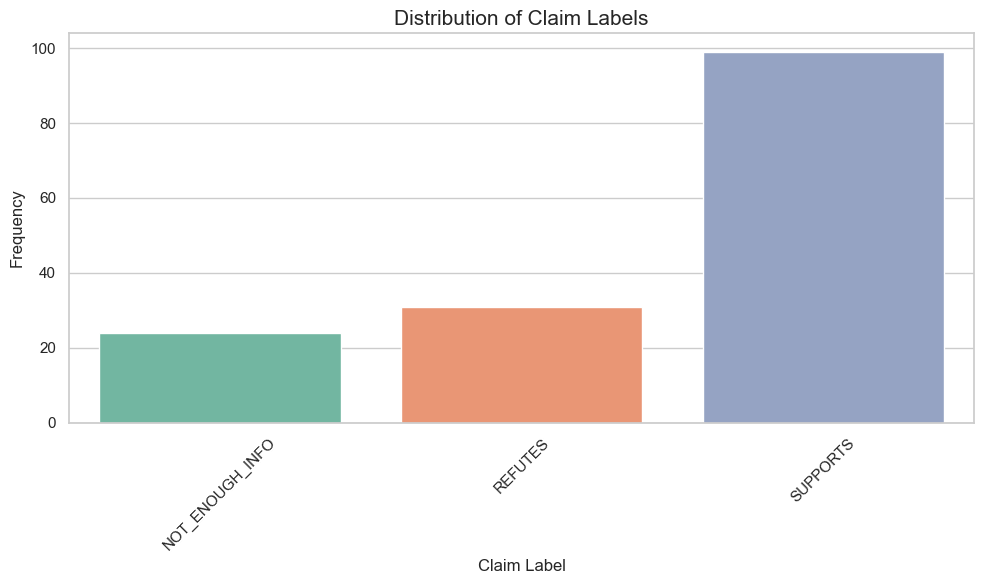

In [ ]:
# Setting the aesthetic style of the plots
sns.set(style="whitegrid")

# Creating a count plot for claim_label
plt.figure(figsize=(10, 6))  # Set the figure size for the plot
ax = sns.countplot(x='claim_label', data=output_df, palette='Set2')  # Set2 is a nice color palette

# Adding titles and labels for clarity
ax.set_title('Distribution of Claim Labels', fontsize=15)
ax.set_xlabel('Claim Label', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Displaying the plot
plt.xticks(rotation=45)  # Rotate the x labels to make them more readable
plt.tight_layout()  # Adjusts plot parameters to give some padding
plt.show()


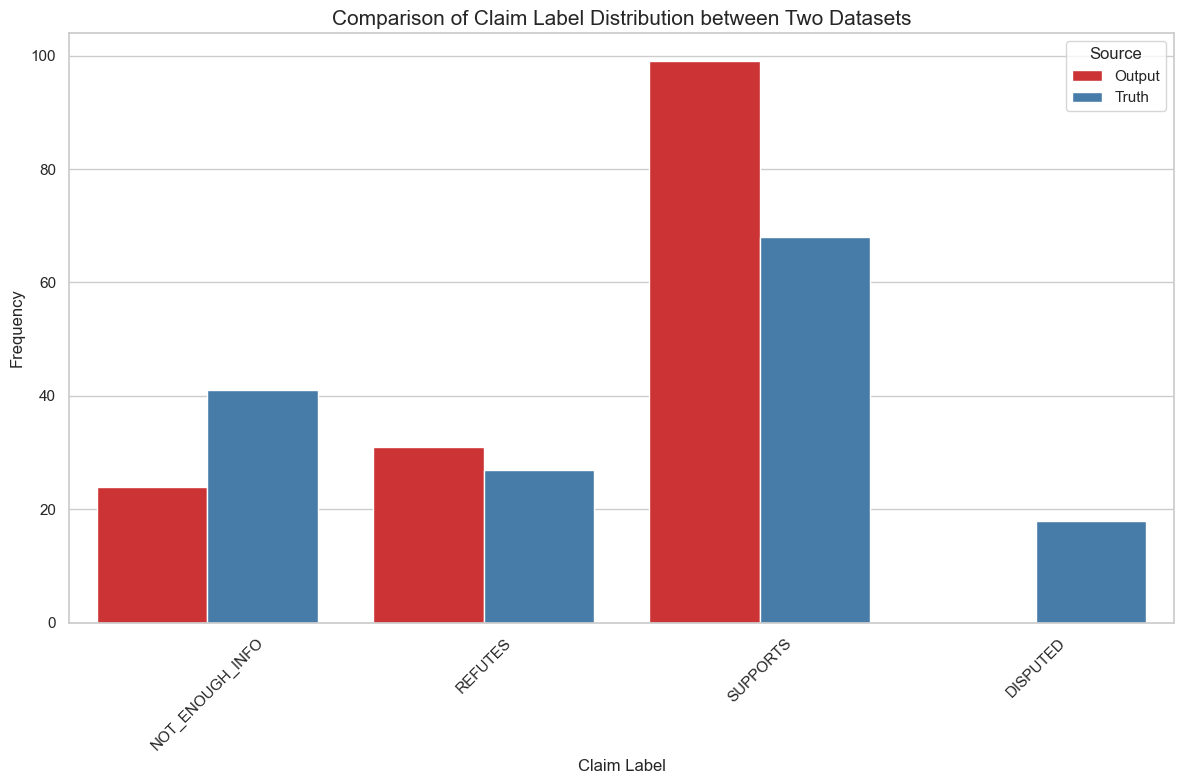

In [ ]:
output_df['source'] = 'Output'
label_df['source'] = 'Truth'
combined_df = pd.concat([output_df, label_df])

# Plotting
plt.figure(figsize=(12, 8))
sns.countplot(x='claim_label', hue='source', data=combined_df, palette='Set1')
plt.title('Comparison of Claim Label Distribution between Two Datasets', fontsize=15)
plt.xlabel('Claim Label', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.show()

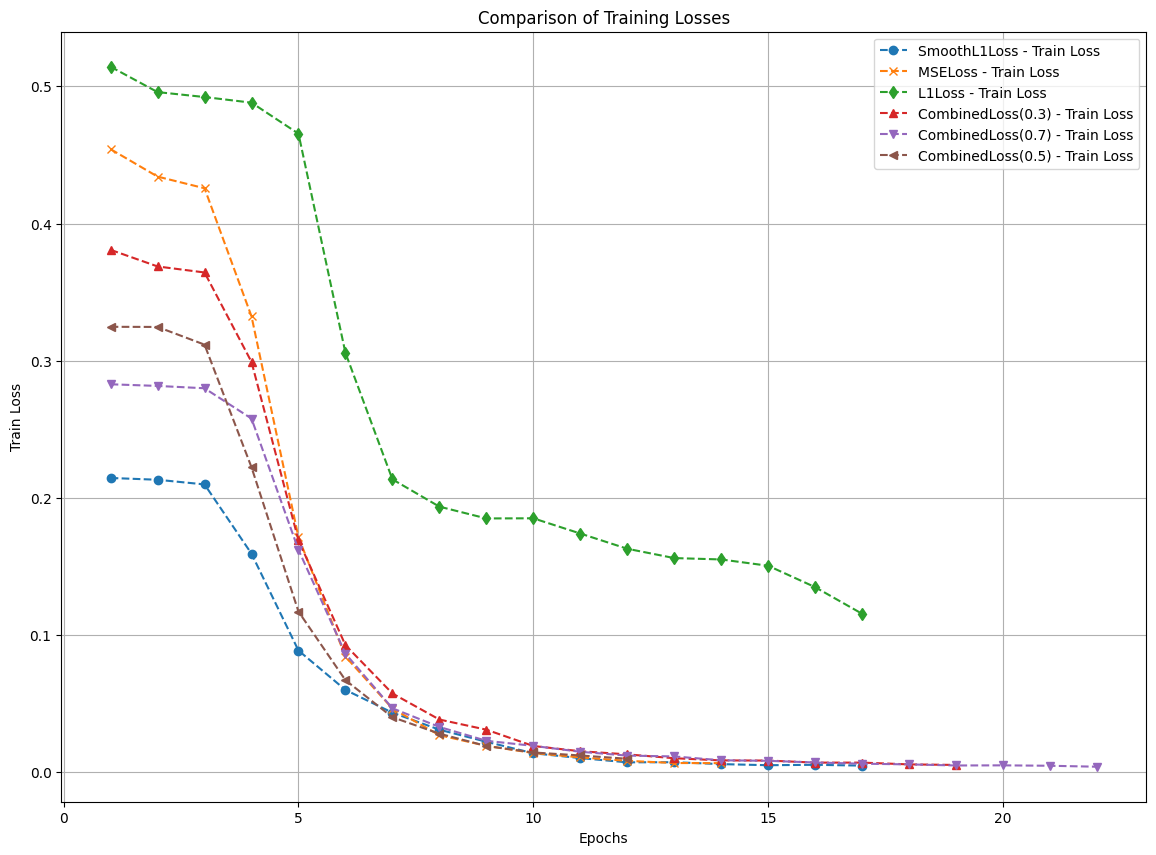

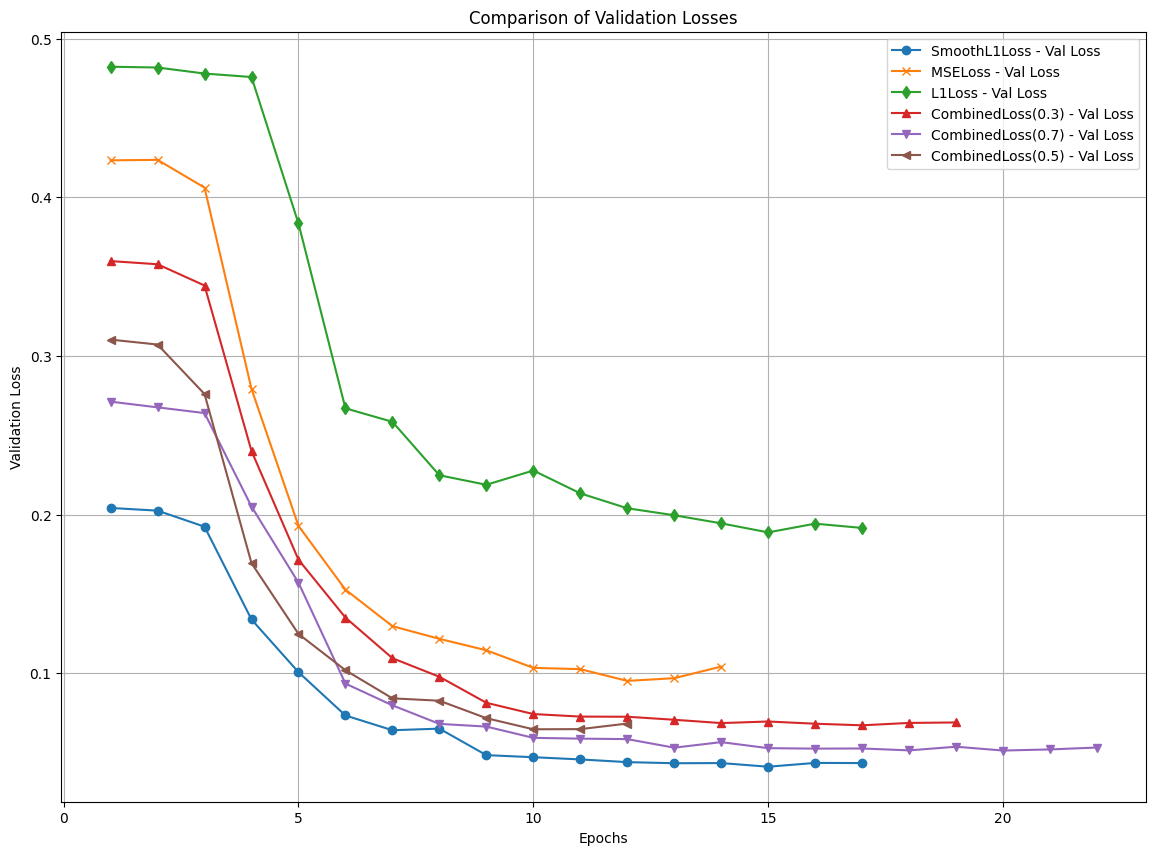

In [375]:
import matplotlib.pyplot as plt

# Data for plotting
epochs_smoothl1 = list(range(1, 18))
train_loss_smoothl1 = [0.2145, 0.2132, 0.2098, 0.1593, 0.0887, 0.0600, 0.0434, 0.0310, 0.0222, 0.0138, 0.0103, 0.0072, 0.0073, 0.0059, 0.0051, 0.0054, 0.0048]
val_loss_smoothl1 = [0.2042, 0.2025, 0.1924, 0.1339, 0.1007, 0.0734, 0.0641, 0.0651, 0.0484, 0.0471, 0.0457, 0.0440, 0.0433, 0.0434, 0.0411, 0.0435, 0.0434]

epochs_mse = list(range(1, 15))
train_loss_mse = [0.4542, 0.4342, 0.4257, 0.3323, 0.1713, 0.0843, 0.0464, 0.0270, 0.0192, 0.0140, 0.0108, 0.0083, 0.0067, 0.0066]
val_loss_mse = [0.4233, 0.4236, 0.4061, 0.2792, 0.1929, 0.1527, 0.1297, 0.1217, 0.1145, 0.1034, 0.1026, 0.0952, 0.0969, 0.1042]

epochs_l1 = list(range(1, 18))
train_loss_l1 = [0.5143, 0.4958, 0.4922, 0.4881, 0.4655, 0.3057, 0.2135, 0.1936, 0.1850, 0.1851, 0.1740, 0.1629, 0.1561, 0.1551, 0.1505, 0.1349, 0.1155]
val_loss_l1 = [0.4823, 0.4818, 0.4780, 0.4758, 0.3835, 0.2670, 0.2585, 0.2248, 0.2188, 0.2278, 0.2134, 0.2040, 0.1996, 0.1945, 0.1888, 0.1943, 0.1916]

epochs_combined_03 = list(range(1, 20))
train_loss_combined_03 = [0.3808, 0.3687, 0.3643, 0.2991, 0.1691, 0.0926, 0.0574, 0.0384, 0.0310, 0.0191, 0.0153, 0.0130, 0.0102, 0.0086, 0.0085, 0.0070, 0.0070, 0.0057, 0.0053]
val_loss_combined_03 = [0.3598, 0.3578, 0.3444, 0.2401, 0.1716, 0.1351, 0.1095, 0.0978, 0.0814, 0.0743, 0.0727, 0.0726, 0.0707, 0.0686, 0.0696, 0.0682, 0.0672, 0.0687, 0.0690]

epochs_combined_07 = list(range(1, 23))
train_loss_combined_07 = [0.2828, 0.2816, 0.2799, 0.2578, 0.1621, 0.0864, 0.0466, 0.0330, 0.0229, 0.0192, 0.0149, 0.0121, 0.0115, 0.0087, 0.0083, 0.0071, 0.0062, 0.0057, 0.0049, 0.0050, 0.0047, 0.0040]
val_loss_combined_07 = [0.2712, 0.2676, 0.2640, 0.2051, 0.1571, 0.0935, 0.0798, 0.0681, 0.0664, 0.0593, 0.0588, 0.0585, 0.0531, 0.0566, 0.0528, 0.0525, 0.0526, 0.0514, 0.0537, 0.0513, 0.0520, 0.0532]

epochs_combined_05 = list(range(1, 13))
train_loss_combined_05 = [0.3247, 0.3246, 0.3117, 0.2223, 0.1171, 0.0671, 0.0401, 0.0281, 0.0191, 0.0144, 0.0122, 0.0098]
val_loss_combined_05 = [0.3103, 0.3072, 0.2760, 0.1694, 0.1248, 0.1019, 0.0842, 0.0827, 0.0717, 0.0647, 0.0648, 0.0683]


# Plotting the training losses
plt.figure(figsize=(14, 10))

# SmoothL1Loss
plt.plot(epochs_smoothl1, train_loss_smoothl1, label='SmoothL1Loss - Train Loss', linestyle='--', marker='o')

# MSELoss
plt.plot(epochs_mse, train_loss_mse, label='MSELoss - Train Loss', linestyle='--', marker='x')

# L1Loss
plt.plot(epochs_l1, train_loss_l1, label='L1Loss - Train Loss', linestyle='--', marker='d')

# CombinedLoss(alpha=0.3)
plt.plot(epochs_combined_03, train_loss_combined_03, label='CombinedLoss(0.3) - Train Loss', linestyle='--', marker='^')

# CombinedLoss(alpha=0.7)
plt.plot(epochs_combined_07, train_loss_combined_07, label='CombinedLoss(0.7) - Train Loss', linestyle='--', marker='v')

# CombinedLoss(alpha=0.5)
plt.plot(epochs_combined_05, train_loss_combined_05, label='CombinedLoss(0.5) - Train Loss', linestyle='--', marker='<')

# Adding labels and title
plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.title('Comparison of Training Losses')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the validation losses
plt.figure(figsize=(14, 10))

# SmoothL1Loss
plt.plot(epochs_smoothl1, val_loss_smoothl1, label='SmoothL1Loss - Val Loss', linestyle='-', marker='o')

# MSELoss
plt.plot(epochs_mse, val_loss_mse, label='MSELoss - Val Loss', linestyle='-', marker='x')

# L1Loss
plt.plot(epochs_l1, val_loss_l1, label='L1Loss - Val Loss', linestyle='-', marker='d')

# CombinedLoss(alpha=0.3)
plt.plot(epochs_combined_03, val_loss_combined_03, label='CombinedLoss(0.3) - Val Loss', linestyle='-', marker='^')

# CombinedLoss(alpha=0.7)
plt.plot(epochs_combined_07, val_loss_combined_07, label='CombinedLoss(0.7) - Val Loss', linestyle='-', marker='v')

# CombinedLoss(alpha=0.5)
plt.plot(epochs_combined_05, val_loss_combined_05, label='CombinedLoss(0.5) - Val Loss', linestyle='-', marker='<')

# Adding labels and title
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Comparison of Validation Losses')
plt.legend()
plt.grid(True)
plt.show()



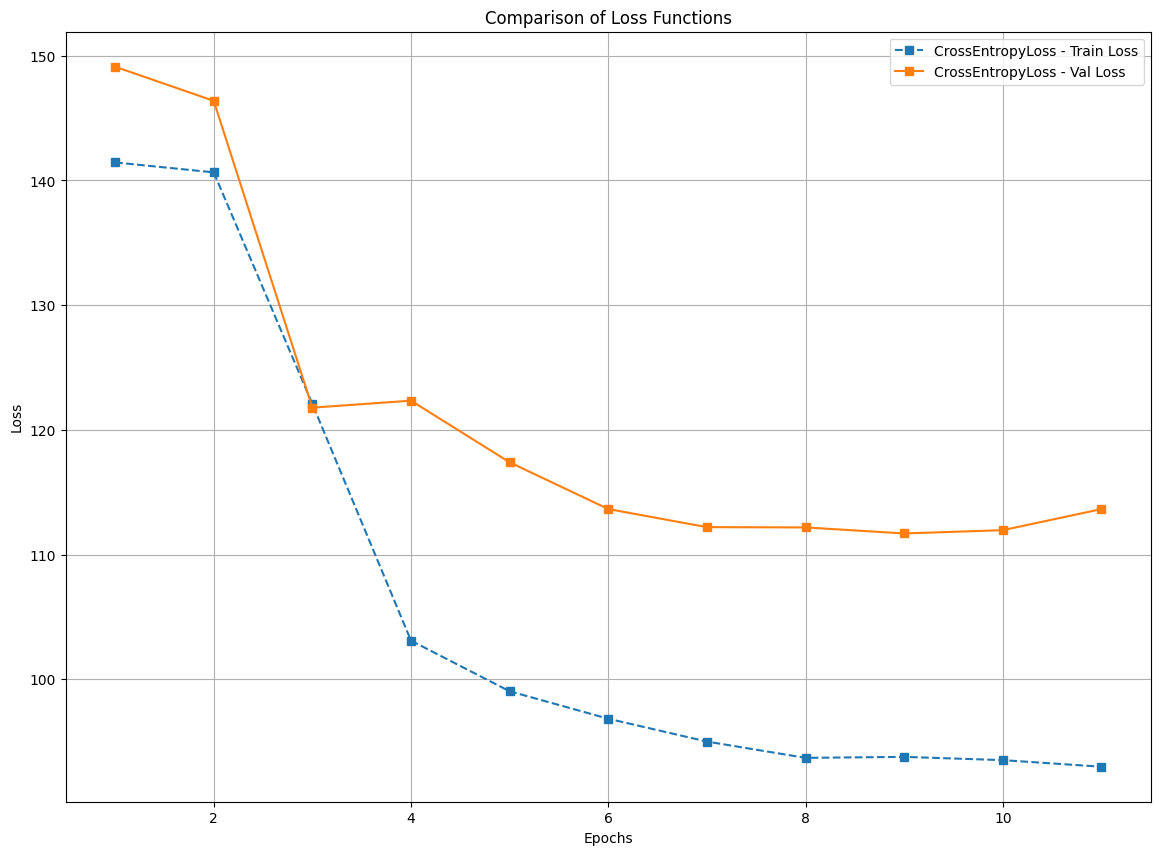

In [373]:
import matplotlib.pyplot as plt


epochs_crossentropy = list(range(1, 12))
train_loss_crossentropy = [141.4423, 140.6459, 122.0784, 103.0989, 99.0398, 96.8390, 95.0087, 93.7013, 93.7822, 93.5197, 92.9913]
val_loss_crossentropy = [149.1162, 146.3821, 121.7806, 122.3409, 117.3991, 113.6506, 112.2001, 112.1778, 111.6940, 111.9580, 113.6475]



# Plotting the data
plt.figure(figsize=(14, 10))


# CrossEntropyLoss
plt.plot(epochs_crossentropy, train_loss_crossentropy, label='CrossEntropyLoss - Train Loss', linestyle='--', marker='s')
plt.plot(epochs_crossentropy, val_loss_crossentropy, label='CrossEntropyLoss - Val Loss', linestyle='-', marker='s')


# Adding labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Comparison of Loss Functions')
plt.legend()
plt.grid(True)
plt.show()
